In [1]:
# Calibration checker
import numpy as np
import os
from tqdm import tqdm
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd

# For splitting into double peak
half1=np.asarray(list(range(0, 34)) + list(range(64, 98)))
def half11(events):
    events = events[np.isin(events[:,0] % 128, half1)]
    return events[np.isin(events[:,1] % 128, half1)]
def half12(events):
    events = events[np.isin(events[:,0] % 128, half1)]
    return events[~np.isin(events[:,1] % 128, half1)]
def half21(events):
    events = events[~np.isin(events[:,0] % 128, half1)]
    return events[np.isin(events[:,1] % 128, half1)]
def half22(events):
    events = events[~np.isin(events[:,0] % 128, half1)]
    return events[~np.isin(events[:,1] % 128, half1)]


In [13]:
data_dir = '/home/kale-chen/Documents/PET/TPPT2026/data/mcenterpgd.bin'
#data_dir = '/home/kale-chen/Documents/PET/TimeCalibration/ToUpload/linepcut3colc.bin'
num_rows = os.path.getsize(data_dir) // 8
data = np.memmap(data_dir, dtype = np.int16, mode = 'r', shape=(num_rows, 4))
print(num_rows)

5928076


In [14]:
bins = np.linspace(-2500, 2500, 200)
bincenters = [(bins[n] + bins[n + 1]) / 2 for n in range(len(bins) - 1)]

hist, hist1, hist2, hist3, hist4 = np.zeros(len(bincenters)), np.zeros(len(bincenters)), np.zeros(len(bincenters)), np.zeros(len(bincenters)), np.zeros(len(bincenters))
for i in tqdm(range(0, num_rows, 1000000)):
    chunk = np.copy(data)[i:i+1000000]
    hist += np.histogram(chunk[:,2], bins = bins)[0]
    hist1 += np.histogram(half11(chunk)[:,2], bins = bins)[0]
    hist2 += np.histogram(half12(chunk)[:,2], bins = bins)[0]
    hist3 += np.histogram(half21(chunk)[:,2], bins = bins)[0]
    hist4 += np.histogram(half22(chunk)[:,2], bins = bins)[0]

100%|██████████| 6/6 [00:01<00:00,  4.71it/s]


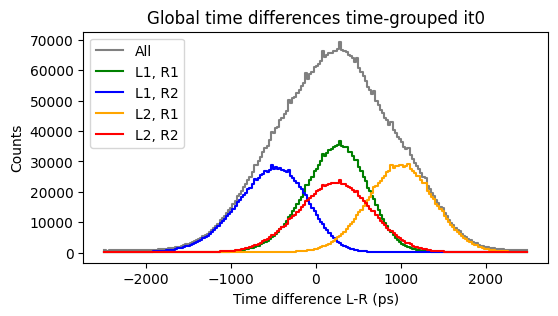

In [15]:
plt.figure(figsize = (6, 3))
plt.step(bincenters, hist, color = 'gray', label = 'All')
plt.step(bincenters, hist1, color = 'green', label = 'L1, R1')
plt.step(bincenters, hist2, color = 'blue', label = 'L1, R2')
plt.step(bincenters, hist3, color = 'orange', label = 'L2, R1')
plt.step(bincenters, hist4, color = 'red', label = 'L2, R2')

plt.legend(loc = 'upper left')
plt.title('Global time differences time-grouped it0')
plt.xlabel('Time difference L-R (ps)')
plt.ylabel('Counts')
plt.savefig(os.path.join(r'/home/kale-chen/Documents/PET/Sensitivity Normalization/writeup/plots/globalctr', f'fullscanner4peaksit0.pdf'), format='pdf', dpi=300, bbox_inches='tight')
plt.show()
plt.show()

In [ ]:
offsets = []
#offsetsdir = r'C:\Users\burri\Documents\PET\TimeCalibration\TimeCalibrationTPPT\time_offset_calibration.tsv'
#offsetsdir = r'C:\Users\burri\Documents\PET\TimeCalibration\CalibrationDataPreparer\tsvtest1.tsv'
#offsetsdir = r'C:\Users\burri\Documents\PET\TimeCalibration\CalibrationDataPreparer\tsvtest2.tsv'
#offsetsdir = r'C:\Users\burri\Documents\PET\TimeCalibration\CalibrationDataPreparer\tsvtest1a.tsv'
#offsetsdir = r'C:\Users\burri\Documents\PET\TimeCalibration\CalibrationDataPreparer\tsvtest2a.tsv'
#offsetsdir = r'C:\Users\burri\Documents\PET\TimeCalibration\CalibrationDataPreparer\tsvtest3.tsv'
#offsetsdir = r'C:\Users\burri\Documents\PET\TimeCalibration\CalibrationDataPreparer\tsvtest2b.tsv'
with open(offsetsdir, 'r') as f:
    for row in f:
        offsets.append(float(row.split()[4]))
offsets = np.asarray(offsets)

def mimiccalibrate(chunk):
    chunk[:, 2] = chunk[:, 2] + offsets[chunk[:, 1]] - offsets[chunk[:, 0] + 3072]
    return chunk

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\burri\\Documents\\PET\\TimeCalibration\\CalibrationDataPreparer\\tsvtest4.tsv'

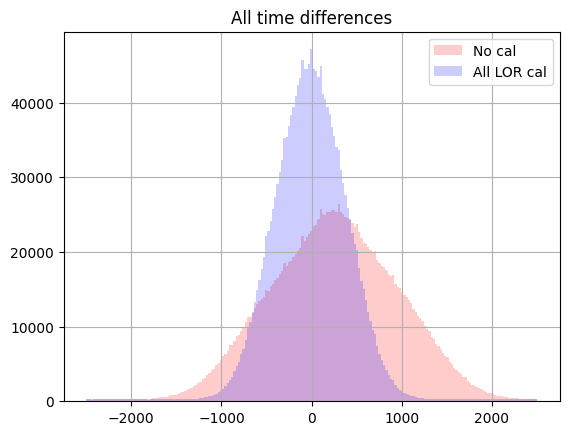

In [24]:
chunk = np.copy(data)
chunk1 = np.copy(data1)
plt.hist(chunk[:,2], bins = bins, color = 'red', alpha = 0.2, label='No cal')
plt.hist(chunk1[:,2], bins = bins, color = 'blue', alpha = 0.2, label = 'All LOR cal')
#calibrated = mimiccalibrate(chunk)
#plt.hist(calibrated[:,2], bins = bins, color = 'purple', alpha = 0.2)
plt.title('All time differences')
plt.grid()
plt.legend()
plt.show()

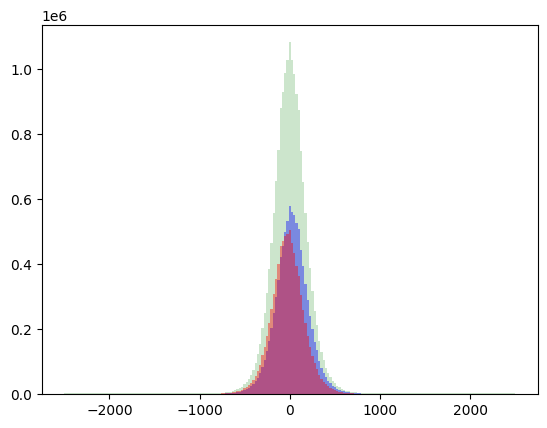

In [ ]:
#plt.hist(chunk[:,2], bins = bins, color = 'purple', alpha = 0.2)
plt.hist(calibrated[:,2], bins = bins, color = 'green', alpha = 0.2)

# For splitting into double peak
half1=np.asarray(list(range(0, 34)) + list(range(64, 98)))
def asichalf1(events):
    return events[np.isin(events[:,1] % 128, half1)]
def asichalf2(events):
    return events[~np.isin(events[:,1] % 128, half1)]

hist1 = plt.hist(asichalf1(calibrated)[:,2], bins = bins, color = 'blue', alpha = 0.4)
hist2 = plt.hist(asichalf2(calibrated)[:,2], bins = bins, color = 'red', alpha = 0.4)

In [71]:

map_dir = 'C:/Users/burri/Downloads/TPPT_Scanner_mapFORCASTOR2.csv'

# Read map
map = pd.read_csv(map_dir, usecols=[0,1,2], header=None)
map = map.to_numpy()

def xpos(idl, idr, td):
    xL, yL, zL = map[idl + 3072]
    xR, yR, zR = map[idr]
    # Midpoint between two channels
    mX = (xL+xR)/2
    deltad = td * 0.15
    d = ((xR-xL)**2+(yR-yL)**2+(zR-zL)**2)**0.5
    sf = deltad / d * (xR - xL)
    return mX + sf

xposs = []
for row in data:
    xposs.append(xpos(row[0], row[1], row[2]))
xpos1 = []
for row in data1:
    xpos1.append(xpos(row[0], row[1], row[2]))

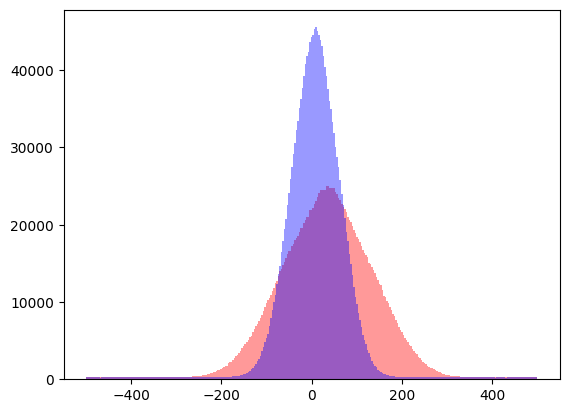

In [72]:
plt.hist(xposs, bins = np.linspace(-500, 500, 300), color = 'red', alpha = 0.4)
plt.hist(xpos1, bins = np.linspace(-500, 500, 300), color = 'blue', alpha = 0.4)
plt.show()